#ETL

In [40]:
pip install pandas matplotlib seaborn numpy scikit-learn scipy imbalanced-learn xgboost

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

check

In [42]:
# Membaca dataset
df = pd.read_csv('/content/sample_data/Teen_Mental_Health_Dataset.csv')

# Menampilkan 5 baris pertama
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


basic info

In [43]:
print("--- Informasi Dataset ---")
df.info()

print("\n--- Statistik Deskriptif ---")
display(df.describe())

print("\n--- Cek Missing Values ---")
print(df.isnull().sum())

print("\n--- Cek Duplikat ---")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
me

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000



--- Cek Missing Values ---
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

--- Cek Duplikat ---
Jumlah data duplikat: 0


ubah platform dan social interaction jadi numerik

> biar bisa dilakukan uji korelasi, kita ubah data yang string itu pake integer biar bisa di cek distribusi nya juga

In [44]:
df['gender'] = df['gender'].map({'male': 1, 'female': 2})
df['platform_usage'] = df['platform_usage'].map({'Instagram': 1, 'TikTok': 2, 'Both' : 3})
df['social_interaction_level'] = df['social_interaction_level'].map({'low': 1, 'medium': 2, 'high': 3})

df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,2,1.9,2,8.0,2.9,3.22,0.8,3,8,1,10,0
2,17,2,1.3,1,7.6,0.5,3.92,0.0,3,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,2,4.7,3,4.9,3.0,2.37,1.4,2,3,5,2,0


#EDA & visualization

cek distribusi data

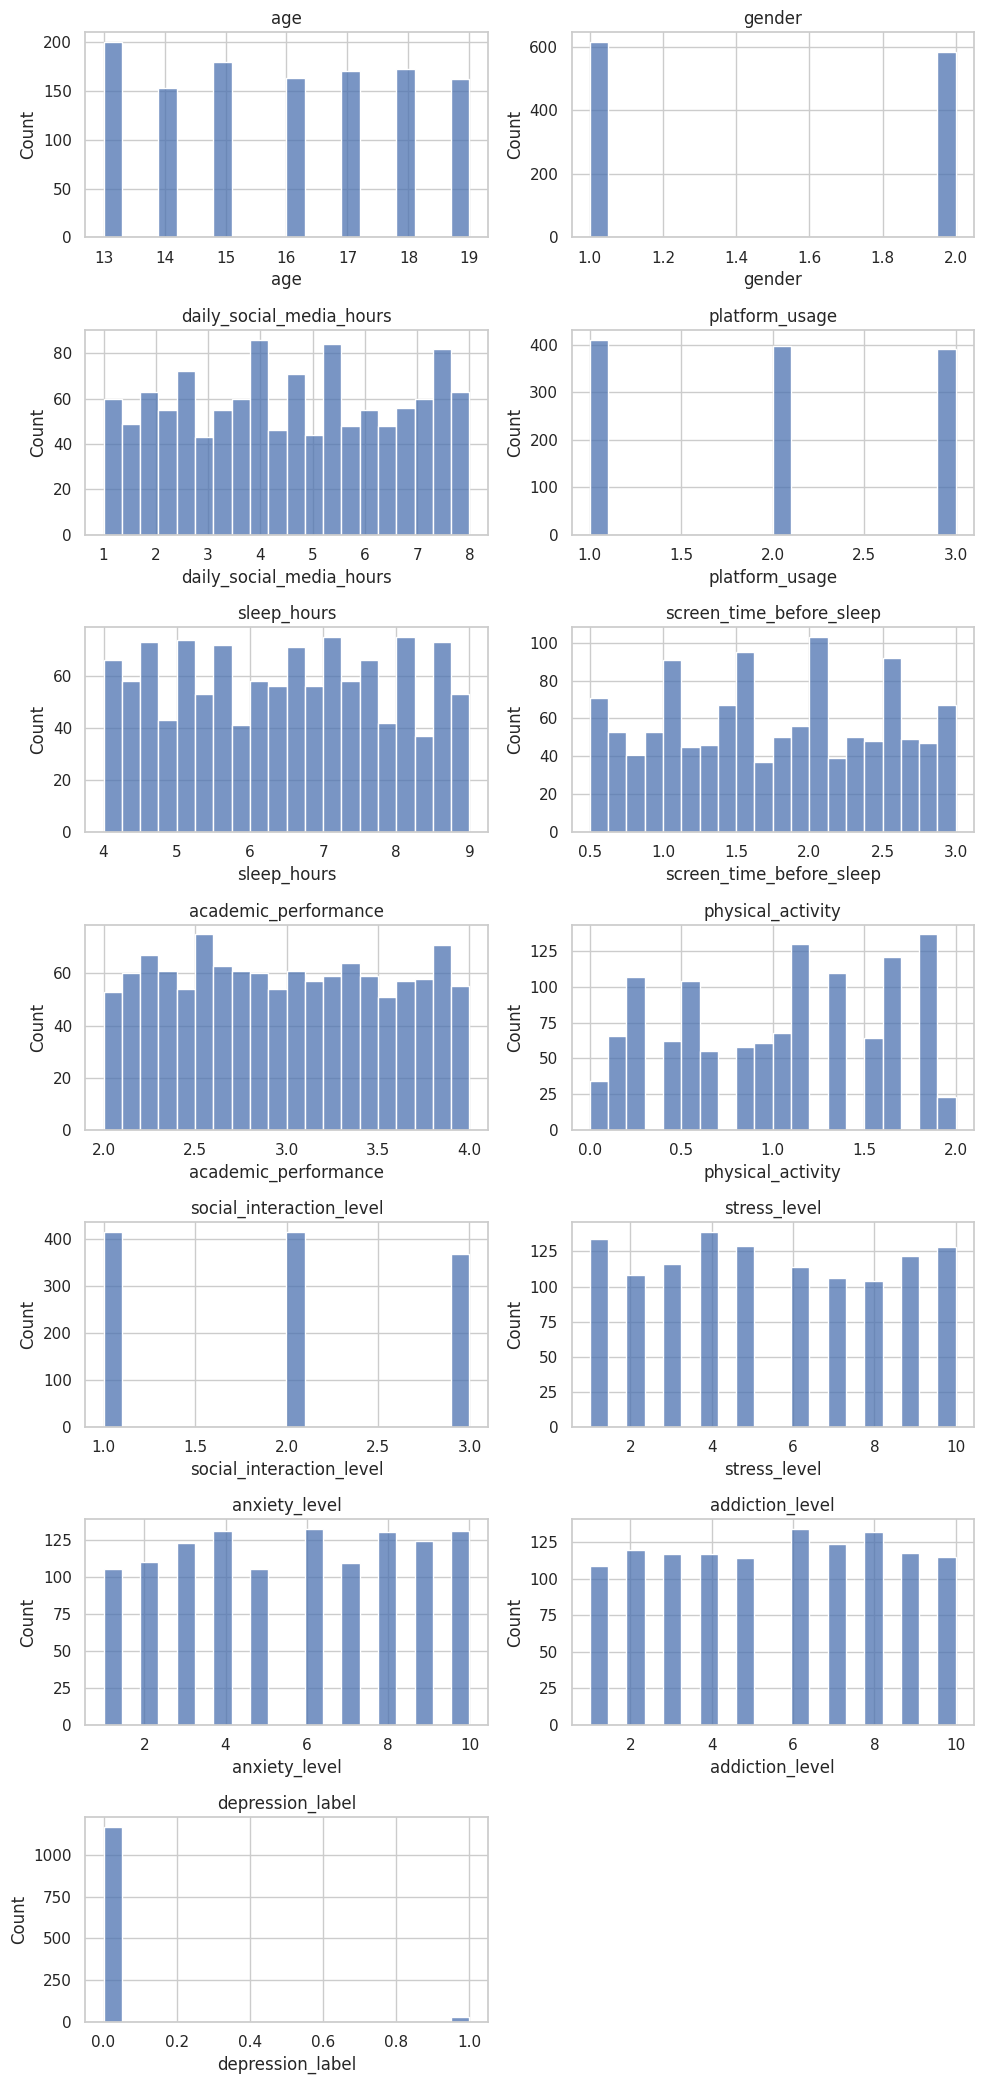

In [45]:
tips = df

# Ambil kolom numerik aja
num_cols = tips.select_dtypes(include='number').columns

n_cols = 2
n_rows = (len(num_cols) + 1) // 2  # biar cukup

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 3))
axes = axes.flatten()  # biar gampang indexing

for i, col in enumerate(num_cols):
    sns.histplot(data=tips, x=col, bins=20, ax=axes[i])
    axes[i].set_title(col)

# Kalau subplot sisa, matiin aja
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Kolmogorov smirnov test

> KS test buat make sure distribusi, semua <0.05 berarti tidak ada distribusi normal



In [46]:
import numpy as np
from scipy import stats

for i,col_name in enumerate(df):
  data = df[col_name]

  # standardisasi (z-score)
  data_std = (data - data.mean()) / np.std(data)

  stat, p_value = stats.kstest(data_std, 'norm')

  print(f"----- {col_name } ------")
  print("Statistic:", stat)
  print("P-value:", p_value)
  print("\n")

----- age ------
Statistic: 0.12565575848547306
P-value: 5.648621533286994e-17


----- gender ------
Statistic: 0.3477954624307777
P-value: 3.267102398371437e-130


----- daily_social_media_hours ------
Statistic: 0.0691449092047296
P-value: 1.964768440242571e-05


----- platform_usage ------
Statistic: 0.22802729875227928
P-value: 2.5338324632740652e-55


----- sleep_hours ------
Statistic: 0.07479102605835247
P-value: 2.772072149210055e-06


----- screen_time_before_sleep ------
Statistic: 0.07684285434723803
P-value: 1.3096215011203806e-06


----- academic_performance ------
Statistic: 0.06899090764791393
P-value: 2.0681038883334033e-05


----- physical_activity ------
Statistic: 0.08543717138480422
P-value: 4.538730296627515e-08


----- social_interaction_level ------
Statistic: 0.22902502537597258
P-value: 8.255544767409774e-56


----- stress_level ------
Statistic: 0.105601762194372
P-value: 4.168814168228817e-12


----- anxiety_level ------
Statistic: 0.11667033492850654
P-value

korelasi

>

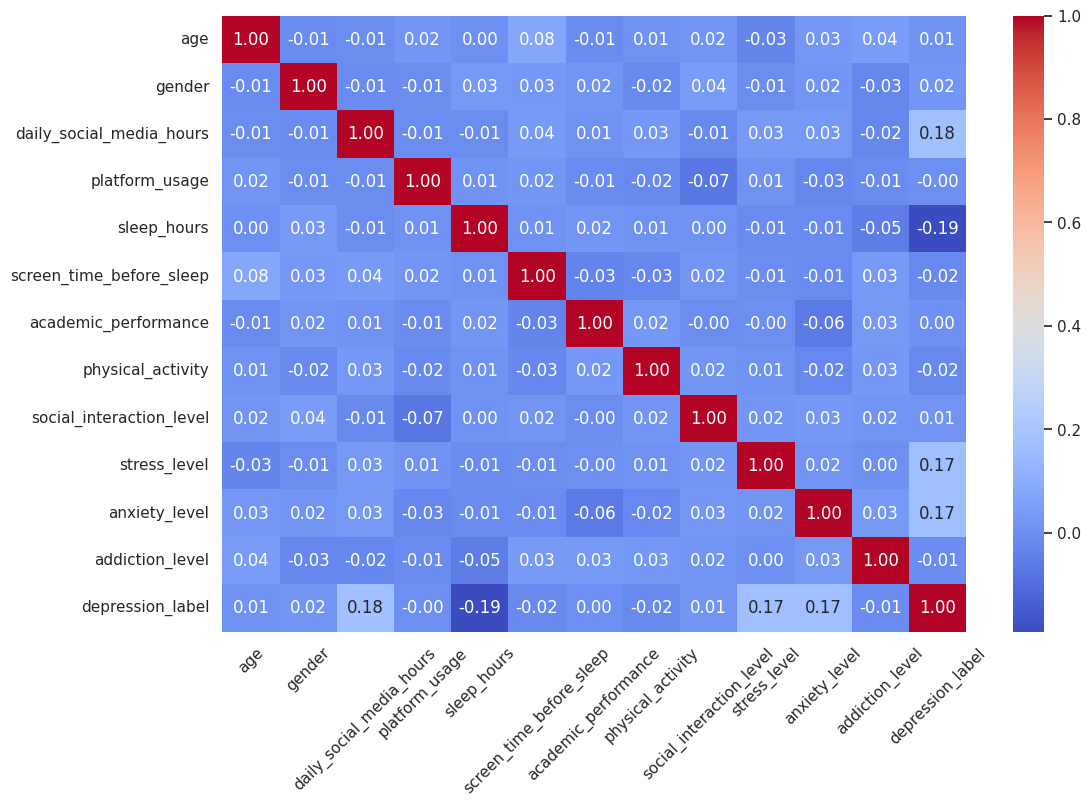

In [47]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(method='spearman'), #pake spearman soalnya distribusi ga normal euy
    annot=True,
    fmt=".2f",   # cuma ambil 2 angka di belakang koma
    cmap="coolwarm"
)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

#MODELLING #1

> menggunakan model Random forest (pake ini karena random forest mampu memproses data tidak linear dan mampu menangkap interaksi antar fitur tanpa feature engineering yang terlalu kompleks)

> menggunakan permutation feature importance (karena permutation lebih versatile)

> menggunakan SMOTENC untuk augmentasi data (karena data campur kategorikal dan kontinu)

imbalanced

In [48]:
count = df['depression_label'].value_counts()
sum = count.sum()
print(count)
print(sum)

depression_label
0    1169
1      31
Name: count, dtype: int64
1200


splitting data

> udah dicoba test_size nya, 0.5; 0.8; 0.3; paling bagus di 0.2

> mungkin karena dataset nya sedikit jadi agak susah nentuin nya, karena ini sangat imbalance nanti kita fokusin jangan di akurasi tapi di recall dan precission

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#X = df[['stress_level','anxiety_level','sleep_hours','daily_social_media_hours']]
X = df.drop(columns=['depression_label'])
feature_names = X.columns
y = df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

pengaplikasian SMOTENC karena data imbalanced ekstrim

In [50]:
from collections import Counter
from imblearn.over_sampling import SMOTENC

#     tergantung pake X yang mana     #
#categorical_features = [0,1]
categorical_features = [0,1,3,8,9,10,11]
#----------------------------------------#

sm = SMOTENC(random_state=42, categorical_features=categorical_features, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 935, 1: 935})


hasil latihan dan confusion matrix


In [51]:
clf = RandomForestClassifier(class_weight='balanced',max_depth=5, random_state=0,)
clf.fit(X_res, y_res)
# print(clf.predict([[0, 0, 0, 0]]))

from sklearn.metrics import classification_report
print(classification_report(y_test, clf.predict(X_test)))

from sklearn.metrics import confusion_matrix
print("\n confusion matrix : ")
confusion_matrix(y_test, clf.predict(X_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


 confusion matrix : 


array([[234,   0],
       [  0,   6]])

feature importance

In [52]:
from sklearn.inspection import permutation_importance
import time

#importance pake recall
start_time = time.time()
result = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='recall'
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=feature_names)

# ---------------------------------------------- #
#importance pake F1 score

start_time = time.time()
result1 = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1'
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances1 = pd.Series(result1.importances_mean, index=feature_names)

#------------------------------------------------------#
#importance pake accuracy

start_time = time.time()
result2 = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='accuracy'
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances2 = pd.Series(result2.importances_mean, index=feature_names)

Elapsed time to compute the importances: 3.217 seconds
Elapsed time to compute the importances: 1.338 seconds
Elapsed time to compute the importances: 1.252 seconds


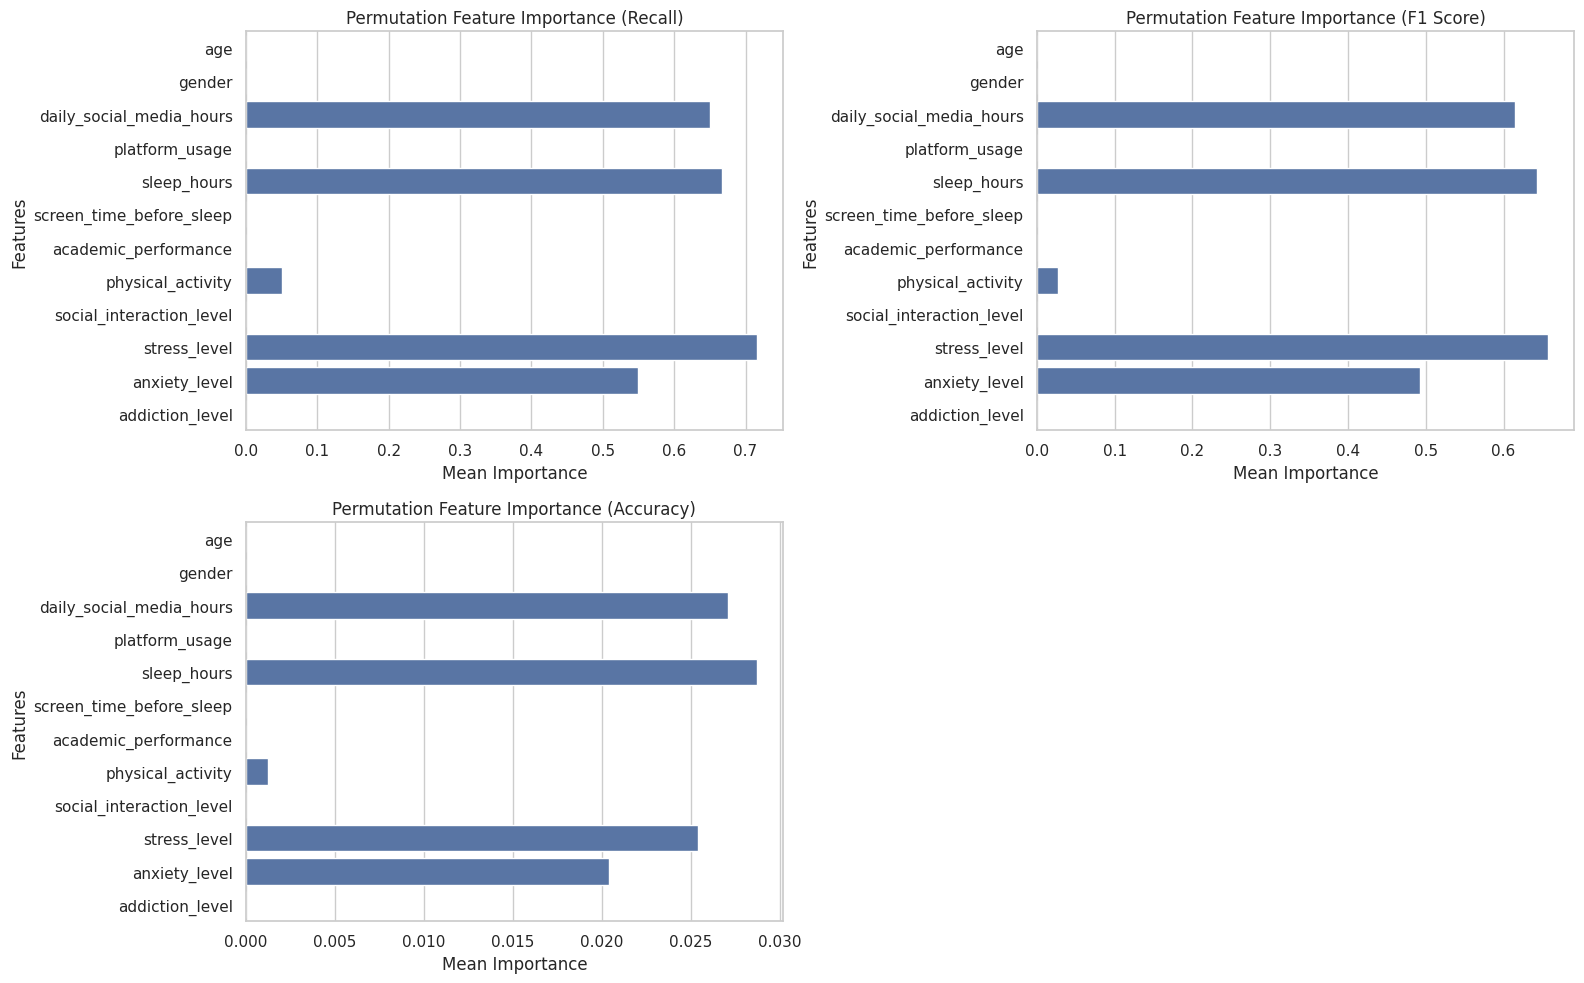

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Recall
sns.barplot(
    x=forest_importances.values,
    y=forest_importances.index,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Permutation Feature Importance (Recall)")
axes[0, 0].set_xlabel("Mean Importance")
axes[0, 0].set_ylabel("Features")


# F1 Score
sns.barplot(
    x=forest_importances1.values,
    y=forest_importances1.index,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Permutation Feature Importance (F1 Score)")
axes[0, 1].set_xlabel("Mean Importance")
axes[0, 1].set_ylabel("Features")


# Accuracy
sns.barplot(
    x=forest_importances2.values,
    y=forest_importances2.index,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Permutation Feature Importance (Accuracy)")
axes[1, 0].set_xlabel("Mean Importance")
axes[1, 0].set_ylabel("Features")


# Kosongin slot terakhir karena baru ada 3 grafik
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

#PIPELINE


In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Cell 1: Train Test Split ---

X = df.drop(columns=['depression_label'])
y = df['depression_label']

# Melakukan Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan shape dari hasil split untuk verifikasi
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)


Shape X_train: (960, 12)
Shape X_test: (240, 12)
Shape y_train: (960,)
Shape y_test: (240,)


In [55]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Cell 2: Pipeline Preprocessing & SMOTE ---

# 1. Mengidentifikasi kolom numerik dan kategorikal secara otomatis
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Mendapatkan index kolom kategorikal untuk SMOTENC (dibutuhkan dalam bentuk list index)
cat_features_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

# 2. Transformer untuk fitur numerik
numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Transformer untuk fitur kategorikal
categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Menggabungkan transformer dalam ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("--- Pipeline Preprocessing & SMOTE ---")

--- Pipeline Preprocessing & SMOTE ---


In [56]:
# --- Cell 3: Transform Data ---

# Fitting preprocessor hanya pada data training untuk menghindari data leakage
preprocessor.fit(X_train)

# Transformasi data training dan testing
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Menampilkan shape hasil transformasi
print(f"Shape X_train_processed: {X_train_processed.shape}")
print(f"Shape X_test_processed: {X_test_processed.shape}")

Shape X_train_processed: (960, 12)
Shape X_test_processed: (240, 12)


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# --- Cell 4: Baseline Model ---

# Menggunakan Logistic Regression sebagai baseline sederhana
baseline_model = LogisticRegression(random_state=42, class_weight='balanced')
baseline_model.fit(X_train_processed, y_train)

y_pred_baseline = baseline_model.predict(X_test_processed)

print("--- Baseline Model Report (Logistic Regression) ---")
print(classification_report(y_test, y_pred_baseline))
confusion_matrix(y_test, y_pred_baseline)

--- Baseline Model Report (Logistic Regression) ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       234
           1       0.46      1.00      0.63         6

    accuracy                           0.97       240
   macro avg       0.73      0.99      0.81       240
weighted avg       0.99      0.97      0.98       240



array([[227,   7],
       [  0,   6]])

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE

# --- Cell 5: Perbandingan Model dengan Pipeline & SMOTE (Fixed) ---

models = {
    'Random Forest': RandomForestClassifier(random_state=42,
                                            n_jobs=-1,
                                            n_estimators=50,
                                            min_samples_split=2,
                                            max_depth=5,
                                            min_samples_leaf=5),
}

print("--- Perbandingan Model (Cross-Validation dengan SMOTE) ---")

# Define StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Kita gunakan SMOTE biasa di sini karena 'preprocessor' sudah mengubah
    # semua data (kategorikal & numerik) menjadi representasi angka sepenuhnya.
    full_model_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    # Evaluasi menggunakan Cross Validation dengan StratifiedKFold
    cv_scores = cross_val_score(full_model_pipeline, X_train, y_train, cv=skf, scoring='f1')
    cv_scores1 = cross_val_score(full_model_pipeline, X_train, y_train, cv=skf, scoring='recall')
    cv_scores2 = cross_val_score(full_model_pipeline, X_train, y_train, cv=skf, scoring='precision')
    cv_scores3 = cross_val_score(full_model_pipeline, X_train, y_train, cv=skf, scoring='accuracy')

    print(f"{name}: Mean F1-Score = {cv_scores.mean():.4f}")
    print(f"{name}: Mean recall-Score = {cv_scores1.mean():.4f}")
    print(f"{name}: Mean precission-Score = {cv_scores2.mean():.4f}")
    print(f"{name}: Mean accuracy-Score = {cv_scores3.mean():.4f}")

--- Perbandingan Model (Cross-Validation dengan SMOTE) ---
Random Forest: Mean F1-Score = 0.8778
Random Forest: Mean recall-Score = 0.8000
Random Forest: Mean precission-Score = 1.0000
Random Forest: Mean accuracy-Score = 0.9948


In [59]:
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# --- Cell 6: Hyperparameter Tuning (Random Forest) dengan Pipeline & SMOTE ---

# Membuat pipeline dasar untuk tuning
tuning_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Menambahkan prefix 'classifier__' pada nama parameter agar merujuk ke model dalam pipeline
param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 5, 10,15,20],
    'classifier__min_samples_split': [2, 5, 7],
    'classifier__min_samples_leaf': [1, 2,3,4,5]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Fit pada data original X_train (bukan yang sudah diproses) karena pipeline akan memprosesnya
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}


In [60]:
from sklearn.metrics import f1_score

# --- Cell 7: Evaluasi Train vs Test (Overfitting Check) ---

# Menggunakan best_pipeline untuk prediksi (otomatis memproses data mentah)
y_train_pred = best_pipeline.predict(X_train)
y_test_pred = best_pipeline.predict(X_test)

f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f"F1 Score Training: {f1_train:.4f}")
print(f"F1 Score Testing: {f1_test:.4f}")

if f1_train > f1_test + 0.1:
    print("\nKesimpulan: Ada indikasi Overfitting (Performa train jauh lebih tinggi dari test).")
else:
    print("\nKesimpulan: Model cukup robust (Performa train dan test seimbang).")

confusion_matrix(y_test,y_test_pred)


F1 Score Training: 0.9796
F1 Score Testing: 1.0000

Kesimpulan: Model cukup robust (Performa train dan test seimbang).


array([[234,   0],
       [  0,   6]])